# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Language Learning Fluently Dataset](https://www.kaggle.com/datasets/sergionefedov/language-learning-to-fluency-who-gets-there?select=language_learning_fluency.csv)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('language_learning_fluency.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,learner_id,fsi_category,related_language,prior_languages,age_started,total_study_hours,active_use_share,immersion_months,speaking_practice,feedback_quality,comprehensible_input_hours,uses_srs,motivation,consistency,accent_nativelike,cefr_level,reached_fluency,dropped_out
0,LNR000000,2,0,0,14,590,0.276,0.0,0.61,1.27,430,0,4.96,7.29,6.66,A2,0,0
1,LNR000001,1,1,1,28,960,0.294,0.0,4.50,7.63,600,0,4.20,6.31,3.90,C1,1,0
2,LNR000002,2,0,0,14,270,0.132,0.0,8.53,0.00,120,1,1.93,6.80,7.57,A1,0,1
3,LNR000003,4,0,0,33,70,0.266,6.5,8.52,5.59,40,0,6.60,9.17,3.84,A0,0,0
4,LNR000004,2,0,0,35,780,0.746,0.0,5.80,4.74,470,1,1.90,6.48,5.97,C1,1,0


## last Five row

In [4]:
df.tail()

,learner_id,fsi_category,related_language,prior_languages,age_started,total_study_hours,active_use_share,immersion_months,speaking_practice,feedback_quality,comprehensible_input_hours,uses_srs,motivation,consistency,accent_nativelike,cefr_level,reached_fluency,dropped_out
44995,LNR044995,4,0,2,26,450,0.258,0.9,6.14,4.88,300,0,3.71,2.85,8.74,A1,0,1
44996,LNR044996,1,0,1,35,360,0.582,0.0,1.93,2.56,240,0,7.60,9.15,6.04,B1,0,0
44997,LNR044997,1,0,1,23,650,0.525,0.6,9.43,5.62,240,0,5.36,7.39,4.53,C2,1,0
44998,LNR044998,2,0,0,31,460,0.885,0.0,10.00,6.63,370,0,5.57,7.89,3.20,B2,1,0
44999,LNR044999,1,1,0,23,390,0.182,0.0,6.63,5.54,310,0,1.68,6.28,7.83,A2,0,0


## Shape of our dataset

In [5]:
df.shape

(45000, 18)

## List out all columns

In [6]:
df.columns

Index(['learner_id', 'fsi_category', 'related_language', 'prior_languages',
       'age_started', 'total_study_hours', 'active_use_share',
       'immersion_months', 'speaking_practice', 'feedback_quality',
       'comprehensible_input_hours', 'uses_srs', 'motivation', 'consistency',
       'accent_nativelike', 'cefr_level', 'reached_fluency', 'dropped_out'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

learner_id                     object
fsi_category                    int64
related_language                int64
prior_languages                 int64
age_started                     int64
total_study_hours               int64
active_use_share              float64
immersion_months              float64
speaking_practice             float64
feedback_quality              float64
comprehensible_input_hours      int64
uses_srs                        int64
motivation                    float64
consistency                   float64
accent_nativelike             float64
cefr_level                     object
reached_fluency                 int64
dropped_out                     int64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   learner_id                  45000 non-null  object 
 1   fsi_category                45000 non-null  int64  
 2   related_language            45000 non-null  int64  
 3   prior_languages             45000 non-null  int64  
 4   age_started                 45000 non-null  int64  
 5   total_study_hours           45000 non-null  int64  
 6   active_use_share            45000 non-null  float64
 7   immersion_months            45000 non-null  float64
 8   speaking_practice           45000 non-null  float64
 9   feedback_quality            45000 non-null  float64
 10  comprehensible_input_hours  45000 non-null  int64  
 11  uses_srs                    45000 non-null  int64  
 12  motivation                  45000 non-null  float64
 13  consistency                 450

## Check Null Value

In [9]:
df.isnull().sum()

learner_id                    0
fsi_category                  0
related_language              0
prior_languages               0
age_started                   0
total_study_hours             0
active_use_share              0
immersion_months              0
speaking_practice             0
feedback_quality              0
comprehensible_input_hours    0
uses_srs                      0
motivation                    0
consistency                   0
accent_nativelike             0
cefr_level                    0
reached_fluency               0
dropped_out                   0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,fsi_category,related_language,prior_languages,age_started,total_study_hours,active_use_share,immersion_months,speaking_practice,feedback_quality,comprehensible_input_hours,uses_srs,motivation,consistency,accent_nativelike,reached_fluency,dropped_out
count,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,2.319822,0.302978,0.802333,28.078556,575.624667,0.399528,1.437027,6.125751,4.998321,316.733111,0.402933,4.989548,6.436488,5.702435,0.357622,0.370667
std,1.134278,0.459551,0.896060,10.743013,429.467155,0.200324,2.735011,2.253452,2.159636,256.929141,0.490493,2.155739,2.167426,1.963940,0.479305,0.482989
min,1.000000,0.000000,0.000000,6.000000,10.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,21.000000,260.000000,0.242000,0.000000,4.570000,3.520000,130.000000,0.000000,3.490000,4.950000,4.370000,0.000000,0.000000
50%,2.000000,0.000000,1.000000,28.000000,470.000000,0.384000,0.000000,6.190000,5.010000,250.000000,0.000000,4.995000,6.510000,5.720000,0.000000,0.000000
75%,3.000000,1.000000,1.000000,35.000000,780.000000,0.543000,1.900000,7.780000,6.490000,430.000000,1.000000,6.480000,8.040000,7.060000,1.000000,1.000000
max,4.000000,1.000000,5.000000,70.000000,4320.000000,0.950000,32.400000,10.000000,10.000000,2610.000000,1.000000,10.000000,10.000000,10.000000,1.000000,1.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

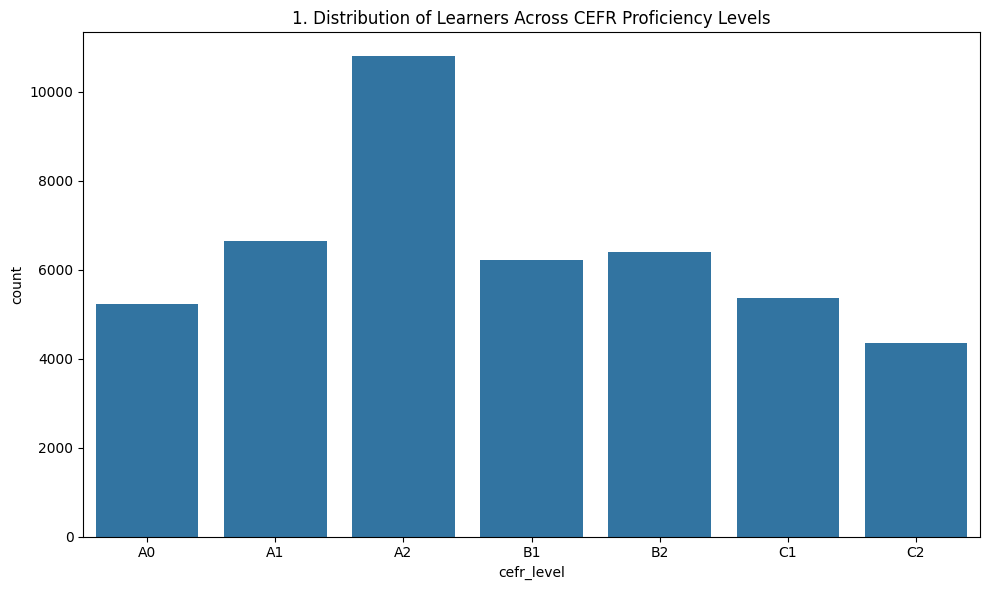

In [13]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='cefr_level', order=sorted(df['cefr_level'].dropna().unique()))
plt.title(f'{plot_no}. Distribution of Learners Across CEFR Proficiency Levels')
show_fig()
plot_no += 1

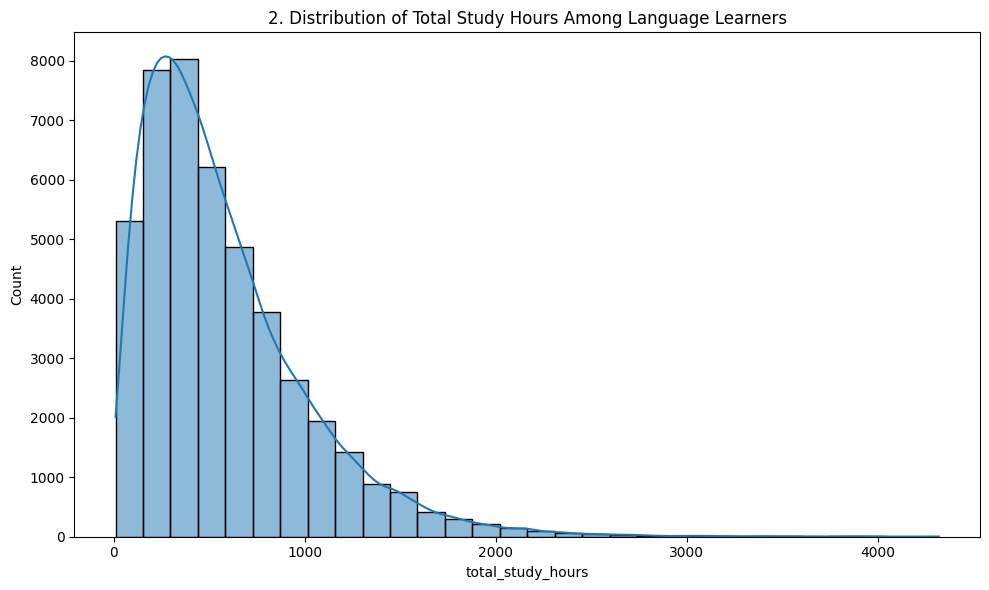

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='total_study_hours', bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Total Study Hours Among Language Learners')
show_fig()
plot_no += 1

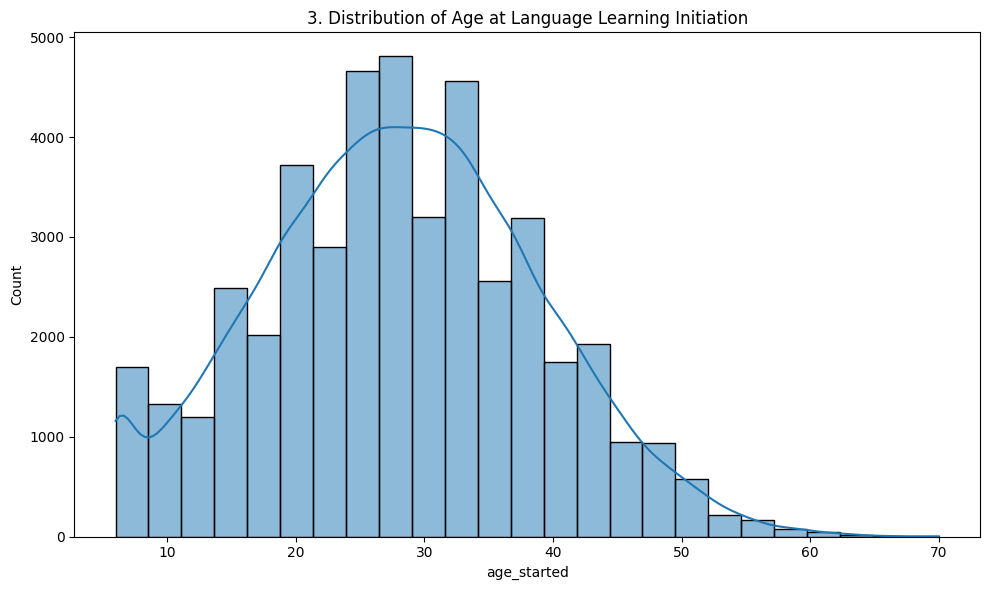

In [15]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='age_started', bins=25, kde=True)
plt.title(f'{plot_no}. Distribution of Age at Language Learning Initiation')
show_fig()
plot_no += 1

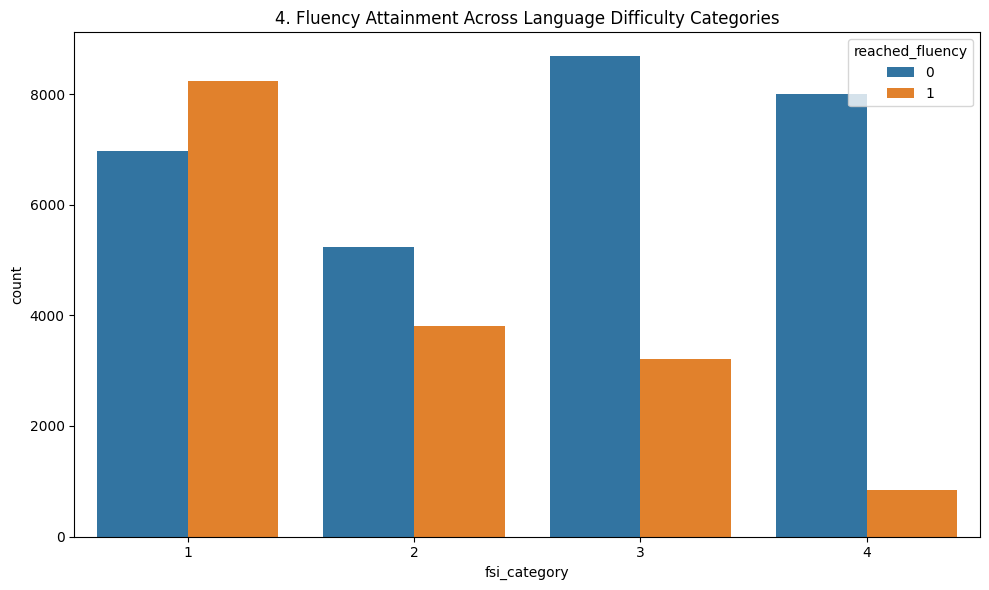

In [16]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='fsi_category', hue='reached_fluency')
plt.title(f'{plot_no}. Fluency Attainment Across Language Difficulty Categories')
show_fig()
plot_no += 1

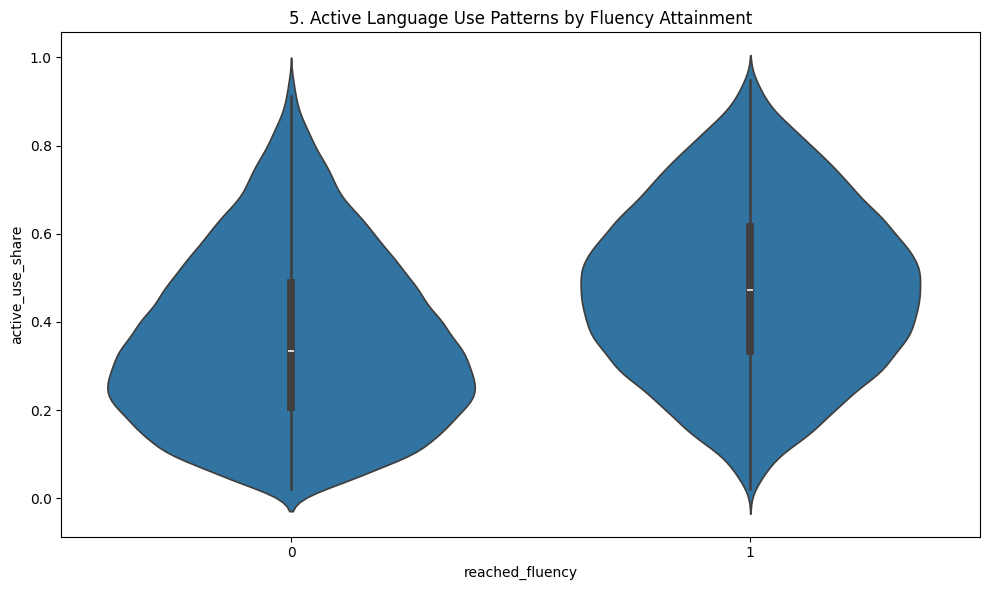

In [17]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='reached_fluency', y='active_use_share')
plt.title(f'{plot_no}. Active Language Use Patterns by Fluency Attainment')
show_fig()
plot_no += 1

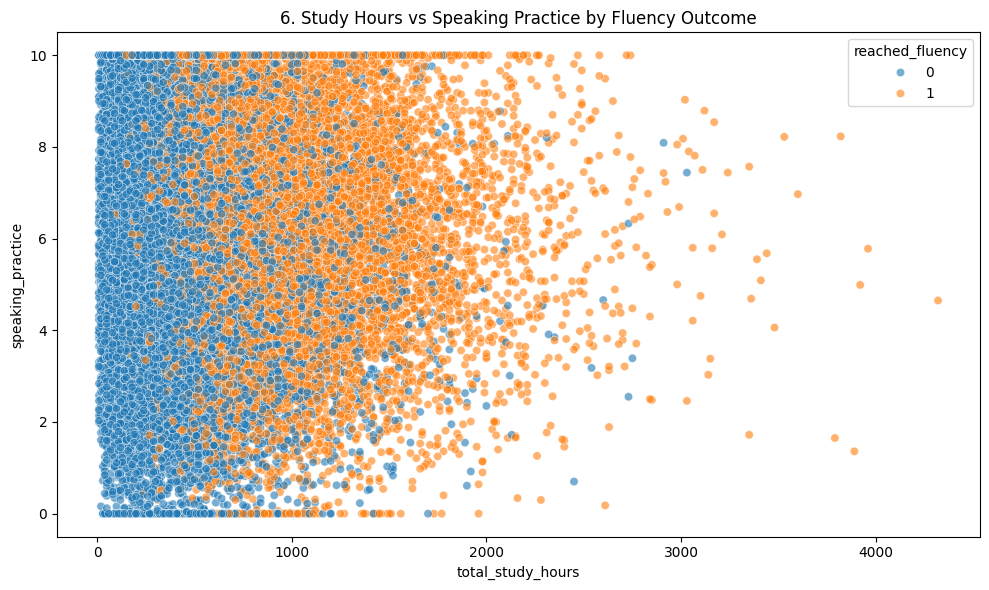

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='total_study_hours', y='speaking_practice', hue='reached_fluency', alpha=0.6)
plt.title(f'{plot_no}. Study Hours vs Speaking Practice by Fluency Outcome')
show_fig()
plot_no += 1

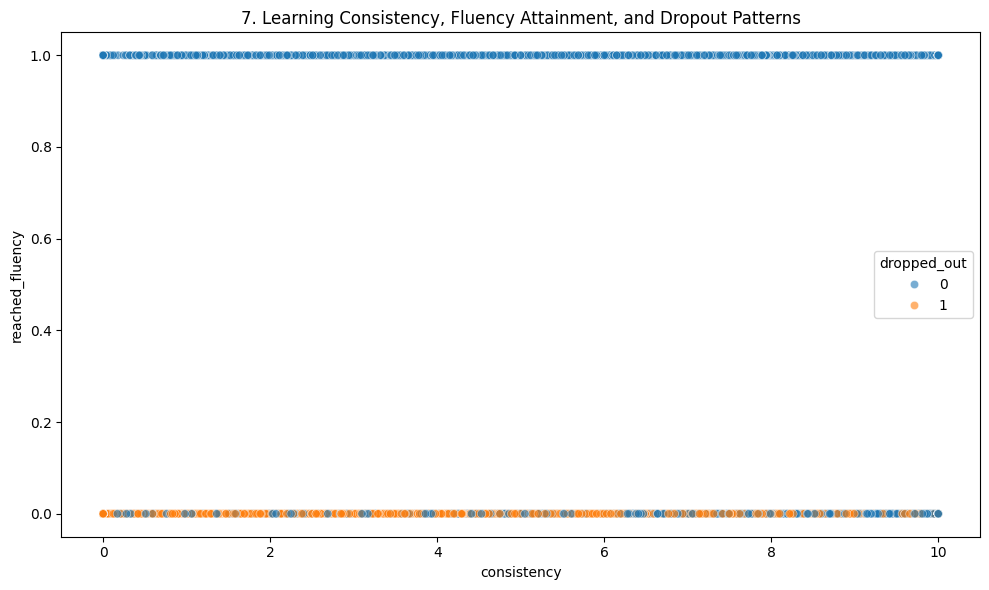

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='consistency', y='reached_fluency', hue='dropped_out', alpha=0.6)
plt.title(f'{plot_no}. Learning Consistency, Fluency Attainment, and Dropout Patterns')
show_fig()
plot_no += 1

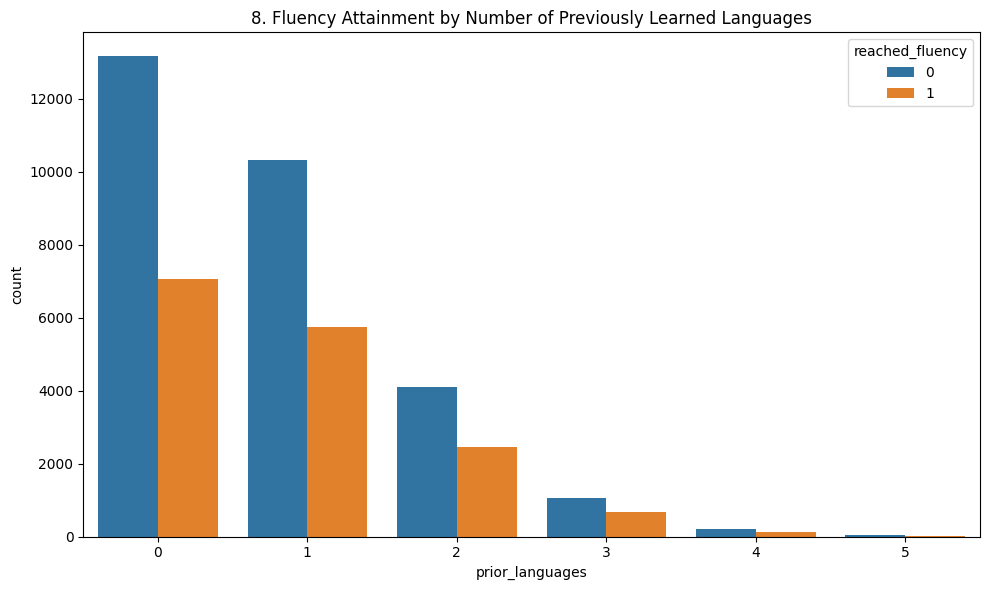

In [20]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='prior_languages', hue='reached_fluency')
plt.title(f'{plot_no}. Fluency Attainment by Number of Previously Learned Languages')
show_fig()
plot_no += 1

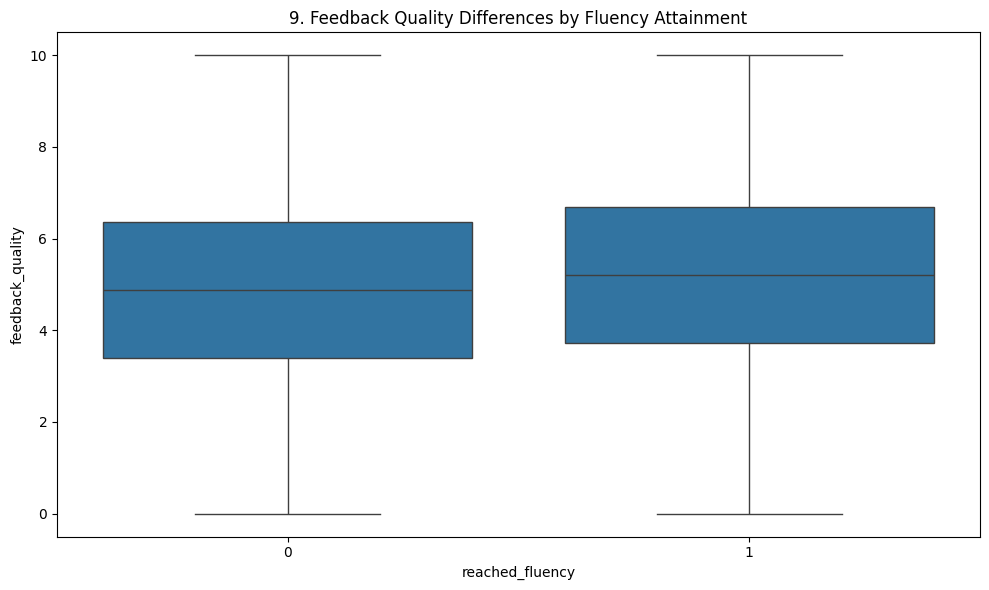

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='reached_fluency', y='feedback_quality')
plt.title(f'{plot_no}. Feedback Quality Differences by Fluency Attainment')
show_fig()
plot_no += 1

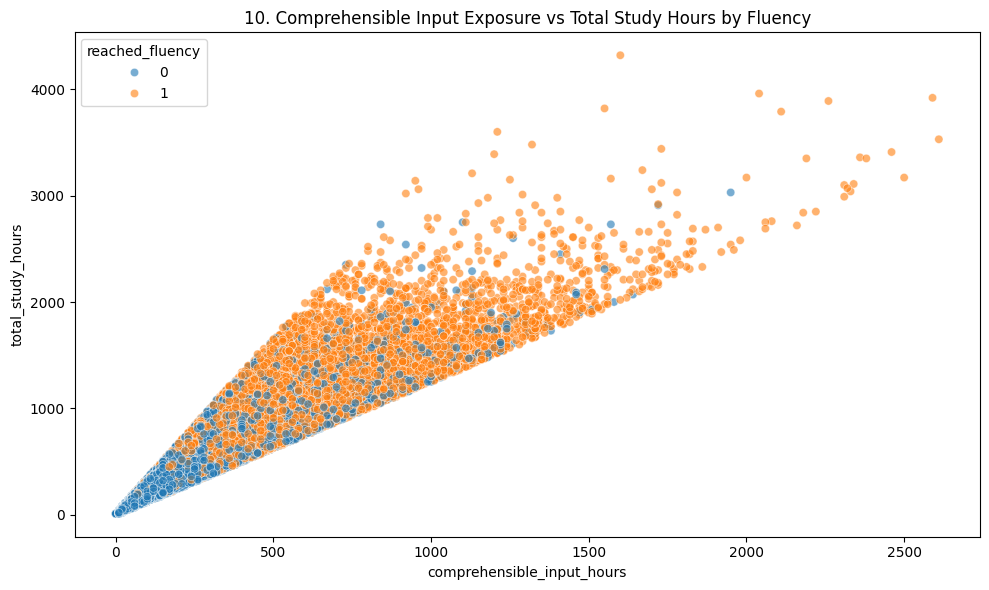

In [22]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='comprehensible_input_hours', y='total_study_hours', hue='reached_fluency', alpha=0.6)
plt.title(f'{plot_no}. Comprehensible Input Exposure vs Total Study Hours by Fluency')
show_fig()
plot_no += 1

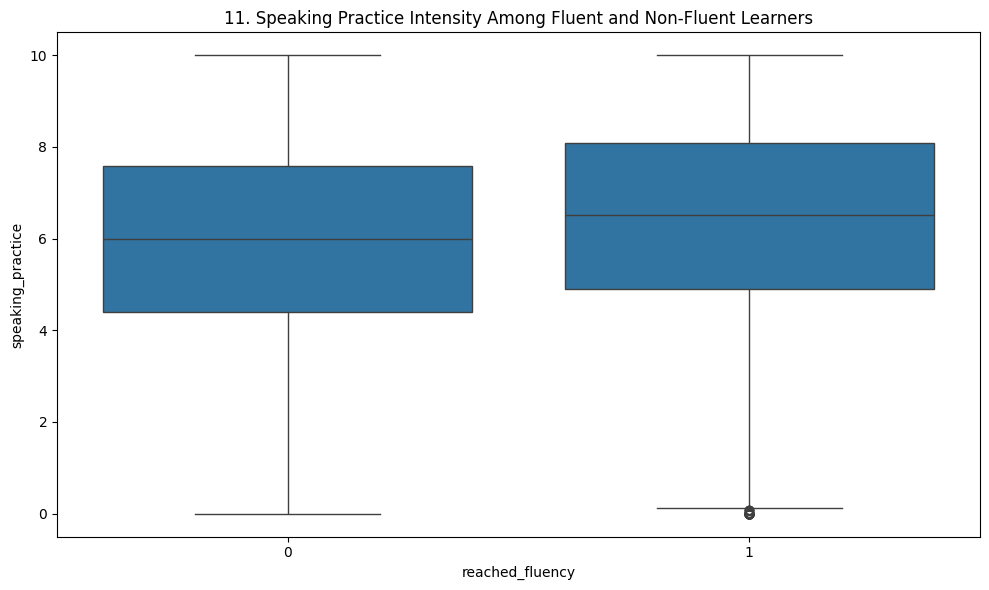

In [23]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='reached_fluency', y='speaking_practice')
plt.title(f'{plot_no}. Speaking Practice Intensity Among Fluent and Non-Fluent Learners')
show_fig()
plot_no += 1

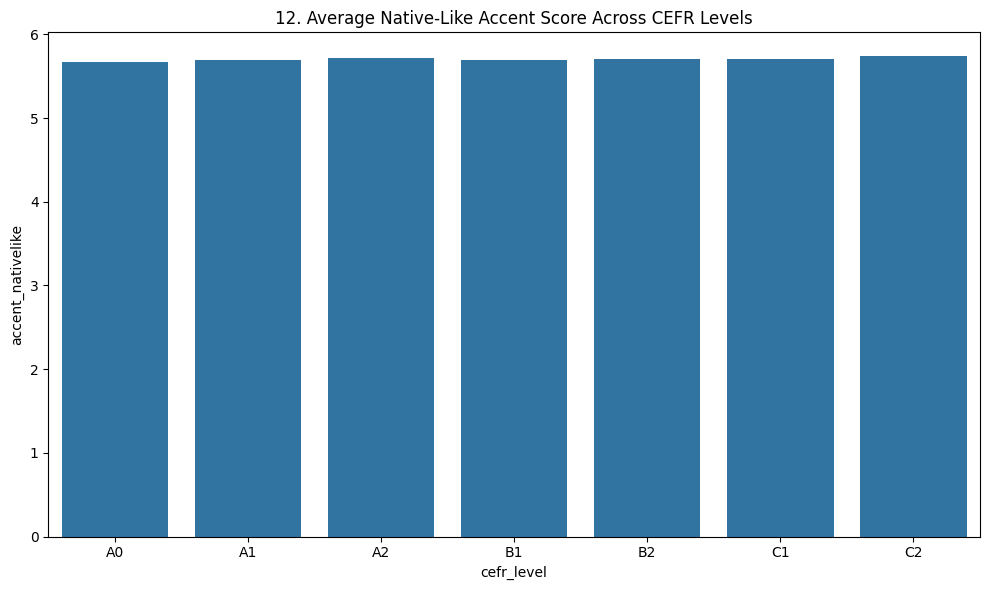

In [24]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='cefr_level', y='accent_nativelike', order=sorted(df['cefr_level'].dropna().unique()), errorbar=None)
plt.title(f'{plot_no}. Average Native-Like Accent Score Across CEFR Levels')
show_fig()
plot_no += 1

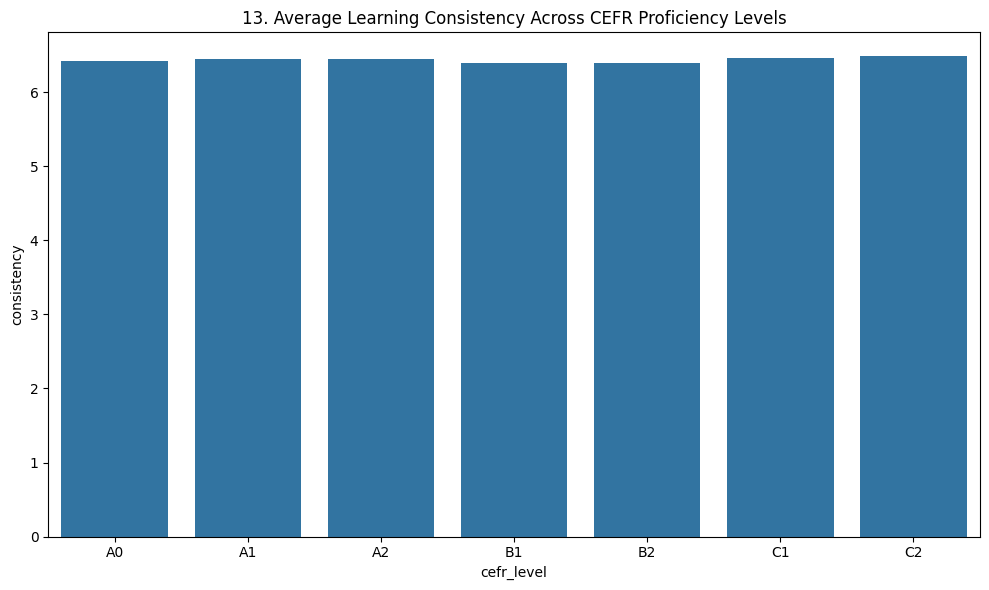

In [25]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='cefr_level', y='consistency', order=sorted(df['cefr_level'].dropna().unique()), errorbar=None)
plt.title(f'{plot_no}. Average Learning Consistency Across CEFR Proficiency Levels')
show_fig()
plot_no += 1

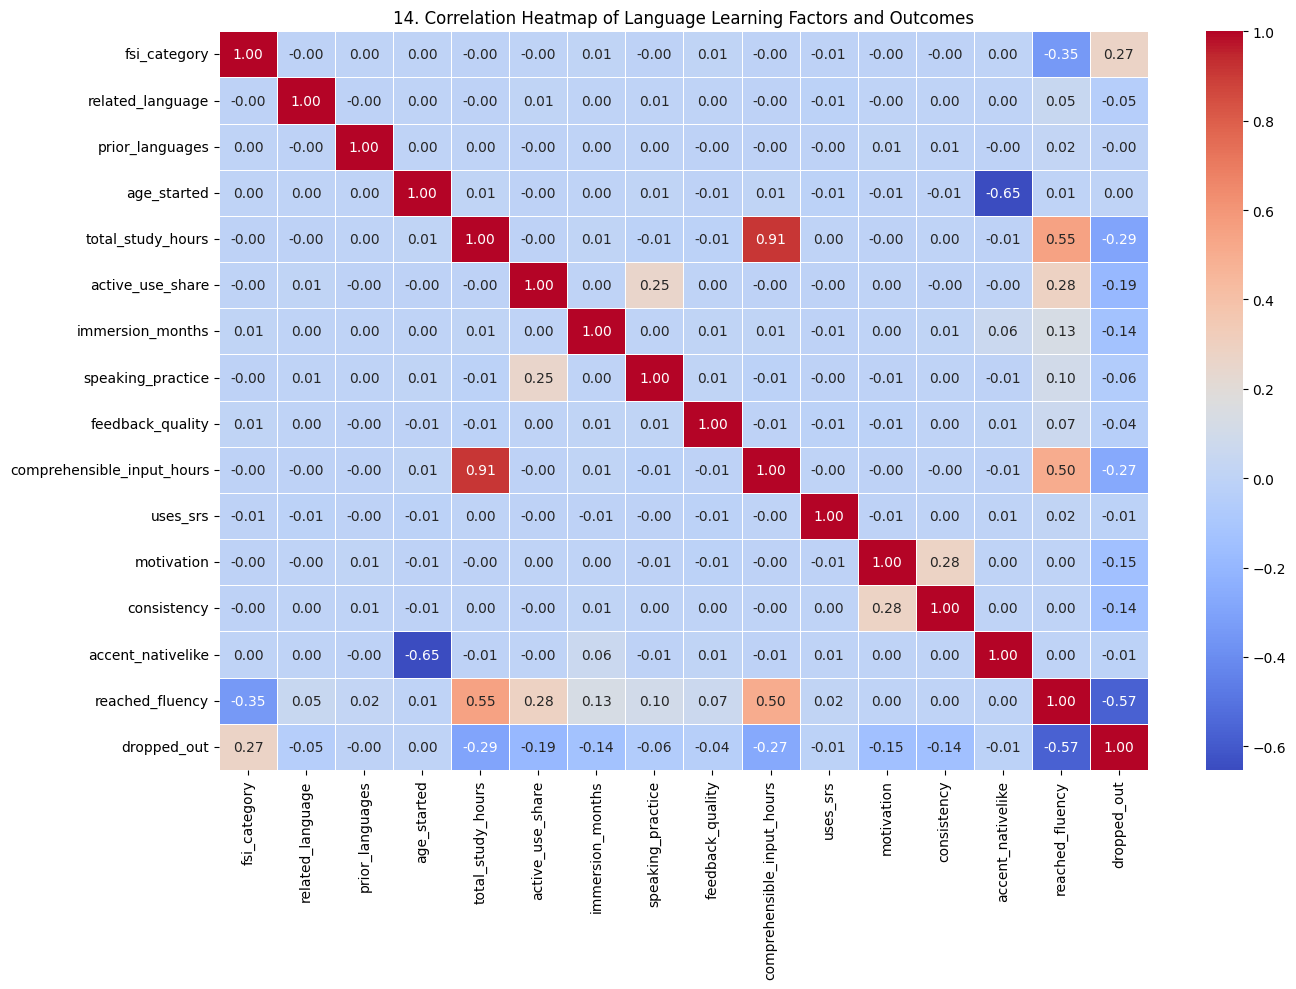

In [26]:
fig = plt.figure(figsize=(14,10))
corr = df.drop(columns=['learner_id'], errors='ignore').corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title(f'{plot_no}. Correlation Heatmap of Language Learning Factors and Outcomes')
show_fig()
plot_no += 1

# Model Training

## Prepare features and target

In [27]:
data = df.drop(columns=['learner_id'], errors='ignore').copy()
X = data.drop(columns=['reached_fluency', 'dropped_out'])
y = data['reached_fluency']

## Identify numerical and categorical columns

In [28]:
num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes(exclude='number').columns

## Split dataset into training and testing sets

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Preprocess missing values and categorical features

In [30]:
preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_cols)
])

## Train a gradient boosting classification model

In [31]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(
        max_iter=200, learning_rate=0.08, max_leaf_nodes=31,
        l2_regularization=1.0, random_state=42
    ))
])

model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Generate predictions

In [32]:
y_pred = model.predict(X_test)

## Print model accuracy and classification report

In [33]:
print("Model: HistGradientBoostingClassifier")
print("Fluency Prediction Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print(classification_report(y_test, y_pred, zero_division=0))

Model: HistGradientBoostingClassifier
Fluency Prediction Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5781
           1       1.00      1.00      1.00      3219

    accuracy                           1.00      9000
   macro avg       1.00      1.00      1.00      9000
weighted avg       1.00      1.00      1.00      9000



## Plot confusion matrix

<Figure size 1000x600 with 0 Axes>

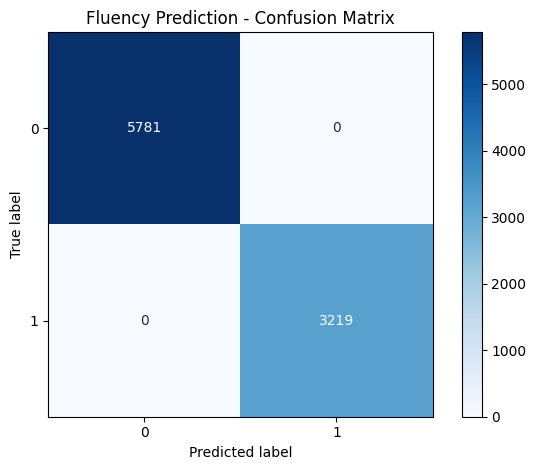

In [34]:
fig = plt.figure(figsize=(10,6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, cmap='Blues', values_format='d'
)
plt.title('Fluency Prediction - Confusion Matrix')
show_fig()